# 05  LLM Labelling + Evaluation vs Regex 


## 0. Setup + CONFIG

In [33]:
!pip install openai
import sys
!{sys.executable} -m pip install openai
import openai
print(openai.__version__)

2.16.0


In [34]:
import os, json, time, ast
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import precision_recall_fscore_support, classification_report, confusion_matrix, accuracy_score
from scipy.stats import binomtest
sns.set_style("whitegrid"); plt.rcParams["figure.dpi"]=110

# CONFIG
MAIN_CSV   = "cleaned_comments_ver2.csv"     
ID_COL     = "Document ID"
TEXT_COL   = "comment_text"
STANCE_COL = "stance"                         
SAMPLE_N   = 150
SEED       = 42

TOPIC_CODES = ["oil_spill_risk","climate_emissions","air_quality","environmental_justice",
               "marine_wildlife","fisheries","wetlands_coast","national_interest"]

TOPIC_DESC = {
 "oil_spill_risk":"oil spills, leaks, blowouts, spill response, Deepwater Horizon, catastrophic accident",
 "climate_emissions":"climate change, greenhouse gas, CO2, fossil fuel expansion, emissions",
 "air_quality":"air pollution, ozone, NOx, local air health",
 "environmental_justice":"impact on low-income / minority / coastal communities, fairness, EJ",
 "marine_wildlife":"sea turtles, marine mammals, dolphins, whales, birds, habitat, ecosystems",
 "fisheries":"fishing industry, shrimp, commercial fishing, fishermen, fishery impacts",
 "wetlands_coast":"wetlands, coastline, erosion, storm surge, sea-level rise, flooding",
 "national_interest":"whether the project is/ isn't in the national interest (general opinion)",
}

# Gemini 
GEMINI_MODEL = "gemini-2.5-flash-lite"
GEMINI_KEY   = os.environ.get("GEMINI_API_KEY", "")

## 1. Load docket

In [35]:
df = pd.read_csv("cleaned_comments_ver2.csv", low_memory=False)
df = df.drop_duplicates(subset=["comment_text"]).reset_index(drop=True)   
print("rows:", len(df))
miss=[c for c in TOPIC_CODES if c not in df.columns]
print("missing topic flag cols:", miss if miss else "none — good")
print("stance values:", df[STANCE_COL].value_counts().to_dict() if STANCE_COL in df.columns else "NO stance col")


rows: 6574
missing topic flag cols: none — good
stance values: {'Oppose': 4505, 'Unclear': 1855, 'Support': 211, 'Attachment only / unknown': 3}


In [36]:
print([c for c in df.columns])

['Document ID', 'Docket ID', 'Title', 'posted_date', 'posted_month', 'posted_year', 'First Name', 'Last Name', 'Organization Name', 'organization_clean', 'City', 'State/Province', 'state_clean', 'Country', 'comment_text', 'comment_length', 'has_inline_text', 'has_attachment', 'attachment_count', 'submission_source', 'exact_form_letter', 'exact_form_letter_group', 'template_family', 'template_family_id', 'stance', 'oil_spill_risk', 'climate_emissions', 'air_quality', 'environmental_justice', 'marine_wildlife', 'fisheries', 'wetlands_coast', 'national_interest', 'request_deny_or_reject', 'request_more_analysis', 'request_protect_wildlife', 'request_address_ej', 'Attachment Files', 'Content Files']


## 2. Build the gold sample to hand-label


In [37]:
import pandas as pd, re
df = pd.read_csv("cleaned_comments_ver2.csv", low_memory=False)
STANCE_COL="stance"; ID_COL="Document ID"; TEXT_COL="comment_text"; SEED=42; TARGET=150
TOPIC_CODES=['oil_spill_risk','climate_emissions','air_quality','environmental_justice',
             'marine_wildlife','fisheries','wetlands_coast','national_interest']

def dedup_key(s):
    return re.sub(r"[^a-z0-9]", "", str(s).lower()[:300])
pool = df[df[TEXT_COL].astype(str).str.strip().str.len()>0].copy()
pool["_key"] = pool[TEXT_COL].apply(dedup_key)
before = len(pool)
pool = pool.drop_duplicates(subset=["_key"]).reset_index(drop=True)
print(f"deduplicate(first 300 characters): {before} -> {len(pool)} comment unique (form letter grouped)")

picked=set(); parts=[]
def take(sub, n, tag):
    sub = sub[~sub[ID_COL].isin(picked)]
    got = sub.sample(min(n,len(sub)), random_state=SEED).copy()
    got["sample_type"]=tag; picked.update(got[ID_COL]); return got

parts.append(take(pool[pool[STANCE_COL]=="Support"], 15, "rare_oversample"))
parts.append(take(pool[pool["fisheries"]==1], 6, "rare_oversample"))
parts.append(take(pool[pool[TEXT_COL].str.contains(r"\bfish|shrimp|fisher", case=False, na=False)], 10, "rare_oversample"))
parts.append(take(pool[pool["national_interest"]==1], 12, "rare_oversample"))
parts.append(take(pool[pool["marine_wildlife"]==1], 10, "rare_oversample"))
parts.append(take(pool[pool["wetlands_coast"]==1], 10, "rare_oversample"))
parts.append(take(pool, TARGET-len(picked), "random"))

gold = pd.concat(parts).drop_duplicates(subset=[ID_COL]).head(TARGET)

gold_out = pd.DataFrame({
    ID_COL: gold[ID_COL].values,
    "comment_text": gold[TEXT_COL].astype(str).str.slice(0,2000).values,
    "sample_type": gold["sample_type"].values,
    "gold_topics": "",      
    "gold_stance": "",      
    "emerging_notes": "",   
})
gold_out.to_csv("to_label_150.csv", index=False)

gold_out["_k"] = gold_out["comment_text"].apply(dedup_key)
dup = gold_out["_k"].duplicated().sum()
print(f"Wrote to_label.csv ({len(gold_out)} rows) |dupicate of first 300 characters: {dup} (must be 0)")
print("  random:", int((gold_out.sample_type=='random').sum()), "| rare:", int((gold_out.sample_type=='rare_oversample').sum()))
print("Codes:", TOPIC_CODES)


deduplicate(first 300 characters): 10195 -> 1519 comment unique (form letter grouped)
Wrote to_label.csv (150 rows) |dupicate of first 300 characters: 0 (must be 0)
  random: 89 | rare: 61
Codes: ['oil_spill_risk', 'climate_emissions', 'air_quality', 'environmental_justice', 'marine_wildlife', 'fisheries', 'wetlands_coast', 'national_interest']


In [38]:
import pandas as pd, re
g = pd.read_csv("label_done_150.csv")   
CODES = {'oil_spill_risk','climate_emissions','air_quality','environmental_justice',
         'marine_wildlife','fisheries','wetlands_coast','national_interest','NONE','ATTACH_ONLY'}

print("total rows:", len(g))
print("column:", list(g.columns))
print()

print("=== gold_topics check ===")
semi = g['gold_topics'].astype(str).str.contains(';').sum()
print(f"rows with (;): {semi} (should be 0,use|)")
bad=set()
for v in g['gold_topics'].dropna().astype(str):
    for t in v.replace(' ','').split('|'):
        if t and t not in CODES: bad.add(t)
print(f"mark not in 8 schema: {bad if bad else 'no'}")

print("\n=== gold_stance check ===")
print(g['gold_stance'].value_counts(dropna=False).to_string())
valid_stance={'oppose','support','unclear'}
bad_s=set(g['gold_stance'].dropna().astype(str).str.strip().str.lower())-valid_stance
print(f"illgeal stance: {bad_s if bad_s else 'no '}")

print("\n=== emerging_notes sample ===")
print(g['emerging_notes'].dropna().head(10).tolist())

print("\n=== process ===")
print(f"gold_topics filled: {g['gold_topics'].astype(str).str.strip().replace('nan','').ne('').sum()}/{len(g)}")
print(f"gold_stance filled: {g['gold_stance'].astype(str).str.strip().replace('nan','').ne('').sum()}/{len(g)}")

total rows: 150
column: ['Document ID', 'comment_text', 'sample_type', 'gold_topics', 'gold_stance', 'emerging_notes']

=== gold_topics check ===
rows with (;): 0 (should be 0,use|)
mark not in 8 schema: no

=== gold_stance check ===
gold_stance
oppose     128
support     16
unclear      6
illgeal stance: no 

=== emerging_notes sample ===
['flood_risk', 'public_health, environmental_review, NEPA_process, flood_risk', 'property_value, flood_risk', 'public_health, environmental_review', 'environmental_review, NEPA_process', 'environmental_review, NEPA_process', 'environmental_review, NEPA_process', 'public_health', 'public_health', 'public_health, environmental_review, NEPA_process']

=== process ===
gold_topics filled: 150/150
gold_stance filled: 150/150


## 3. LLM labelling 

In [39]:

GEMINI_MODEL = "gemini-2.5-flash-lite"

GEMINI_KEY = os.environ.get("GEMINI_API_KEY", "")


In [40]:
from openai import OpenAI

client = OpenAI(api_key=GEMINI_KEY,
                base_url="https://generativelanguage.googleapis.com/v1beta/openai/",
                timeout=30, max_retries=0)

topic_block = "\n".join([f"- {c}: {TOPIC_DESC[c]}" for c in TOPIC_CODES])
SYSTEM = f"""You label public comments on a US offshore oil port (GulfLink).
Assign ALL applicable TOPIC codes (multi-label) from this fixed list ONLY:
{topic_block}

Also give STANCE = the commenter's position on the project:
- oppose  = against the project (incl. raising harms/pollution as reasons to reject)
- support = in favour
- unclear = neutral / mixed / question only / no position

Return ONLY raw JSON, no prose, no markdown code fences:
{{"topics": ["code", ...], "stance": "oppose|support|unclear", "confidence": 0.0, "uncertain": false}}
Rules: topics must be from the list; if none apply -> []. If you can't decide topic -> uncertain:true, topics:[].
confidence 0-1 = overall certainty."""

VALID=set(TOPIC_CODES)

def llm_label(text):
    """Robust: fails fast (max 3 short retries), never hangs the loop."""
    text=str(text)[:4000]
    last_err=None
    for k in range(3):                    
        try:
            r=client.chat.completions.create(model=GEMINI_MODEL,
                messages=[{"role":"system","content":SYSTEM},
                          {"role":"user","content":text}],
                temperature=0)
            raw=r.choices[0].message.content or ""
            raw=raw.strip().replace("```json","").replace("```","").strip()
            o=json.loads(raw)
            o["topics"]=[t for t in o.get("topics",[]) if t in VALID]
            o["FAILED"]=False; o["err"]=""
            return o
        except Exception as e:
            last_err=str(e)
            wait = min(2**k, 5)             
            if "429" in last_err or "rate" in last_err.lower():
                wait = 8
            time.sleep(wait)
    return {"topics":[], "stance":"unclear", "confidence":0.0,
            "uncertain":True, "FAILED":True, "err":last_err or "unknown"}

print("Testing one call...")
_t = llm_label("This project will pollute our water and harm sea turtles. I strongly oppose it.")
print(_t)
if _t.get("FAILED"):
    print("\n*** STILL FAILING — read err above. Do NOT run the 150 loop yet. ***")
else:
    print("\nOK — Gemini works. You can run the 150-row cell now.")


Testing one call...
{'topics': ['oil_spill_risk', 'marine_wildlife'], 'stance': 'oppose', 'confidence': 1.0, 'uncertain': False, 'FAILED': False, 'err': ''}

OK — Gemini works. You can run the 150-row cell now.


In [41]:
# Run LLM on the gold rows 
gl = pd.read_csv("label_done_150.csv")
recs=[]
for i,row in gl.iterrows():
    o=llm_label(row["comment_text"])
    recs.append({ID_COL:row[ID_COL],
                 "llm_topics":"|".join(o["topics"]) or "NONE",
                 "llm_stance":o.get("stance","unclear"),
                 "llm_conf":o.get("confidence",0.0),
                 "llm_uncertain":o.get("uncertain",False),
                 "llm_failed":o.get("FAILED",False),
                 "llm_err":o.get("err","")})
    if (i+1)%10==0: print(f"{i+1}/{len(gl)}  (failed so far: {sum(r['llm_failed'] for r in recs)})")
    time.sleep(0.2)                     
llm = pd.DataFrame(recs)
llm.to_csv("gold_llm.csv",index=False)

n_fail=int(llm["llm_failed"].sum())
print(f"\nSaved gold_llm.csv  |  {len(llm)} rows, {n_fail} FAILED ({n_fail/len(llm):.0%})")
if n_fail>0:
    print("Sample failure reasons:")
    for e in llm.loc[llm.llm_failed,"llm_err"].head(3): print("  -", str(e)[:120])


10/150  (failed so far: 0)
20/150  (failed so far: 0)
30/150  (failed so far: 0)
40/150  (failed so far: 0)
50/150  (failed so far: 0)
60/150  (failed so far: 0)
70/150  (failed so far: 0)
80/150  (failed so far: 0)
90/150  (failed so far: 0)
100/150  (failed so far: 0)
110/150  (failed so far: 0)
120/150  (failed so far: 0)
130/150  (failed so far: 0)
140/150  (failed so far: 0)
150/150  (failed so far: 0)

Saved gold_llm.csv  |  150 rows, 0 FAILED (0%)


In [42]:

n_fail=int(llm["llm_failed"].sum())
frac=n_fail/len(llm)
print(f"LLM rows: {len(llm)} | failed: {n_fail} ({frac:.0%})")
print(f"llm_stance == 'unclear': {(llm['llm_stance']=='unclear').sum()}")
print(f"llm_topics == 'NONE':    {(llm['llm_topics']=='NONE').sum()}")
print(f"llm_conf == 0.0:         {(llm['llm_conf']==0.0).sum()}")
print()
if frac>0.2:
    print("STOP: >20% of rows FAILED (rate limiting). The evaluation below will be")
    print("      meaningless (LLM recall will look ~0.15 because failed rows default")
    print("      to empty/unclear). Fix: top up the Groq PAID tier, then re-run cell 12.")
    print("      Do NOT report these numbers to Meg/Colin.")
elif frac>0:
    print(f"OK-ish: {n_fail} failed rows. Evaluation will EXCLUDE them (see eval cell).")
else:
    print("GOOD: 0 failures. Full clean LLM run — evaluation below is valid.")


LLM rows: 150 | failed: 0 (0%)
llm_stance == 'unclear': 3
llm_topics == 'NONE':    3
llm_conf == 0.0:         1

GOOD: 0 failures. Full clean LLM run — evaluation below is valid.


## 4. Pull REGEX predictions for the same rows


In [43]:
reg = df[df[ID_COL].isin(gl[ID_COL])].copy()
def regex_topics(r):
    ts=[c for c in TOPIC_CODES if c in r.index and bool(r[c])]
    return "|".join(ts) if ts else "NONE"
reg["regex_topics"]=reg.apply(regex_topics,axis=1)
stance_map={"Oppose":"oppose","Support":"support","Unclear":"unclear",
            "Attachment only / unknown":"unclear","Attachment only / see attached":"unclear"}
reg["regex_stance"]=reg[STANCE_COL].map(stance_map).fillna("unclear")
reg=reg[[ID_COL,"regex_topics","regex_stance"]]
print(reg.head())


              Document ID                                   regex_topics  \
107  MARAD-2019-0093-0170                                           NONE   
120  MARAD-2019-0093-0184                                 wetlands_coast   
182  MARAD-2019-0093-0247  oil_spill_risk|marine_wildlife|wetlands_coast   
209  MARAD-2019-0093-0274                                           NONE   
216  MARAD-2019-0093-0281  oil_spill_risk|marine_wildlife|wetlands_coast   

    regex_stance  
107       oppose  
120      unclear  
182       oppose  
209      support  
216       oppose  


## 5. Assemble evaluation frame (gold + llm + regex on same IDs)

In [44]:
E = gl.merge(llm,on=ID_COL,how="left").merge(reg,on=ID_COL,how="left")

EXCLUDE_FAILED = True   
if EXCLUDE_FAILED and "llm_failed" in E.columns:
    n0=len(E); E=E[~E["llm_failed"].fillna(True)].copy()
    print(f"Excluded {n0-len(E)} LLM-failed rows -> evaluating on {len(E)} clean rows")
    print("(NOTE: regex is scored on these SAME rows, so the comparison stays fair.)")

def parse(s):
    if pd.isna(s): return []
    return [t for t in str(s).replace(" ","").split("|") if t in TOPIC_CODES]
E["gold_set"]  = E["gold_topics"].apply(parse)
E["llm_set"]   = E["llm_topics"].apply(parse)
E["regex_set"] = E["regex_topics"].apply(parse)
E["gold_stance"]=E["gold_stance"].str.strip().str.lower()
print("eval rows:", len(E))


Excluded 0 LLM-failed rows -> evaluating on 150 clean rows
(NOTE: regex is scored on these SAME rows, so the comparison stays fair.)
eval rows: 150


---
## 6. TOPIC evaluation (multi-label)

In [45]:
mlb=MultiLabelBinarizer(classes=TOPIC_CODES)
Y=mlb.fit_transform(E["gold_set"])
P_llm=mlb.transform(E["llm_set"]); P_reg=mlb.transform(E["regex_set"])

def topic_scores(y,p):
    out={}
    for avg in ["micro","macro"]:
        pr,rc,f1,_=precision_recall_fscore_support(y,p,average=avg,zero_division=0)
        out[avg]=dict(P=pr,R=rc,F1=f1)
    return out
def boot_ci(y,p,avg="micro",n=1000):
    rng=np.random.default_rng(SEED); v=[]
    for _ in range(n):
        idx=rng.integers(0,len(y),len(y))
        _,_,f1,_=precision_recall_fscore_support(y[idx],p[idx],average=avg,zero_division=0)
        v.append(f1)
    return np.percentile(v,2.5),np.percentile(v,97.5)

for name,P in [("REGEX",P_reg),("LLM",P_llm)]:
    s=topic_scores(Y,P); lo,hi=boot_ci(Y,P)
    print(f"\n{name}")
    print(f"  micro  P={s['micro']['P']:.3f} R={s['micro']['R']:.3f} F1={s['micro']['F1']:.3f}  (95% CI {lo:.3f}-{hi:.3f})")
    print(f"  macro  P={s['macro']['P']:.3f} R={s['macro']['R']:.3f} F1={s['macro']['F1']:.3f}")



REGEX
  micro  P=0.866 R=0.714 F1=0.783  (95% CI 0.746-0.817)
  macro  P=0.845 R=0.652 F1=0.714

LLM
  micro  P=0.685 R=0.914 F1=0.783  (95% CI 0.745-0.819)
  macro  P=0.668 R=0.909 F1=0.754


In [46]:

def per_topic(y,p):
    pr,rc,f1,sup=precision_recall_fscore_support(y,p,average=None,zero_division=0,labels=range(len(TOPIC_CODES)))
    return pd.DataFrame({"topic":TOPIC_CODES,"support":sup,"P":pr,"R":rc,"F1":f1})
pt=per_topic(Y,P_reg).merge(per_topic(Y,P_llm),on=["topic","support"],suffixes=("_regex","_llm"))
print(pt[["topic","support","R_regex","R_llm","F1_regex","F1_llm"]].round(3).to_string(index=False))
print("\nLook where R_llm >> R_regex: those are the nuanced/technical topics regex misses (your pollution intuition).")


                topic  support  R_regex  R_llm  F1_regex  F1_llm
       oil_spill_risk       57    0.772  0.860     0.854   0.778
    climate_emissions      113    0.903  1.000     0.940   0.942
          air_quality       63    0.476  0.952     0.625   0.816
environmental_justice       40    0.875  0.950     0.824   0.576
      marine_wildlife       54    0.685  0.926     0.804   0.833
            fisheries       15    0.200  0.933     0.316   0.622
       wetlands_coast       50    0.680  0.940     0.654   0.691
    national_interest       62    0.629  0.710     0.696   0.772

Look where R_llm >> R_regex: those are the nuanced/technical topics regex misses (your pollution intuition).


McNemar (topic exact-match): regex-only-right=30, llm-only-right=24, p=0.4966
p<0.05 => methods differ significantly on topic labelling.


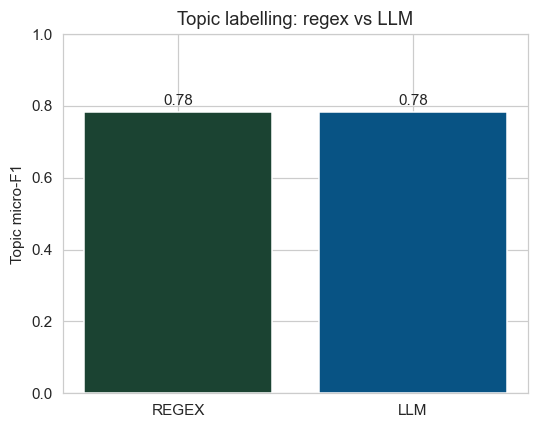

In [47]:
# McNemar: regex vs llm
c_llm=(P_llm==Y).all(axis=1); c_reg=(P_reg==Y).all(axis=1)
b=int((c_reg&~c_llm).sum()); c=int((~c_reg&c_llm).sum())
p=binomtest(min(b,c),b+c,0.5).pvalue if (b+c)>0 else 1.0
print(f"McNemar (topic exact-match): regex-only-right={b}, llm-only-right={c}, p={p:.4f}")
print("p<0.05 => methods differ significantly on topic labelling.")

# chart
f1s=[topic_scores(Y,P_reg)['micro']['F1'],topic_scores(Y,P_llm)['micro']['F1']]
plt.figure(figsize=(5,4)); plt.bar(["REGEX","LLM"],f1s,color=["#1B4332","#085384"])
plt.ylim(0,1); plt.ylabel("Topic micro-F1")
for i,v in enumerate(f1s): plt.text(i,v+0.02,f"{v:.2f}",ha="center")
plt.title("Topic labelling: regex vs LLM"); plt.tight_layout()
plt.savefig("eval_topic_f1.png",bbox_inches="tight"); plt.show()


---
## 7. STANCE evaluation (single-label: oppose/support/unclear)
accuracy + macro-F1 + per-class report + confusion matrix + McNemar.

In [48]:
labels=["oppose","support","unclear"]
g=E["gold_stance"]
for name,col in [("REGEX","regex_stance"),("LLM","llm_stance")]:
    pred=E[col].str.strip().str.lower()
    acc=accuracy_score(g,pred)
    _,_,f1,_=precision_recall_fscore_support(g,pred,labels=labels,average="macro",zero_division=0)
    print(f"\n{name}: accuracy={acc:.3f}  macro-F1={f1:.3f}")
    print(classification_report(g,pred,labels=labels,zero_division=0))



REGEX: accuracy=0.647  macro-F1=0.507
              precision    recall  f1-score   support

      oppose       0.99      0.63      0.77       128
     support       0.46      0.69      0.55        16
     unclear       0.11      0.83      0.20         6

    accuracy                           0.65       150
   macro avg       0.52      0.72      0.51       150
weighted avg       0.90      0.65      0.72       150


LLM: accuracy=0.980  macro-F1=0.885
              precision    recall  f1-score   support

      oppose       0.98      1.00      0.99       128
     support       1.00      1.00      1.00        16
     unclear       1.00      0.50      0.67         6

    accuracy                           0.98       150
   macro avg       0.99      0.83      0.89       150
weighted avg       0.98      0.98      0.98       150



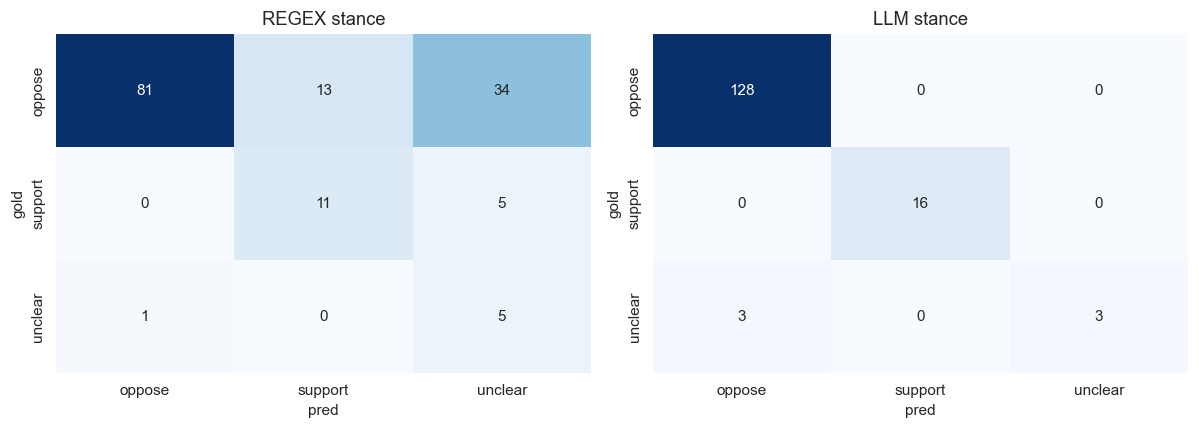

McNemar (stance): regex-only-right=2, llm-only-right=52, p=0.0000


In [49]:
# Confusion matrices side by side
fig,ax=plt.subplots(1,2,figsize=(11,4))
for a,(name,col) in zip(ax,[("REGEX","regex_stance"),("LLM","llm_stance")]):
    cm=confusion_matrix(g,E[col].str.strip().str.lower(),labels=labels)
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=labels,yticklabels=labels,ax=a,cbar=False)
    a.set_title(f"{name} stance"); a.set_xlabel("pred"); a.set_ylabel("gold")
plt.tight_layout(); plt.savefig("eval_stance_cm.png",bbox_inches="tight"); plt.show()

# McNemar on stance correctness
cl=(E["llm_stance"].str.lower()==g); cr=(E["regex_stance"].str.lower()==g)
b=int((cr&~cl).sum()); c=int((~cr&cl).sum())
p=binomtest(min(b,c),b+c,0.5).pvalue if (b+c)>0 else 1.0
print(f"McNemar (stance): regex-only-right={b}, llm-only-right={c}, p={p:.4f}")


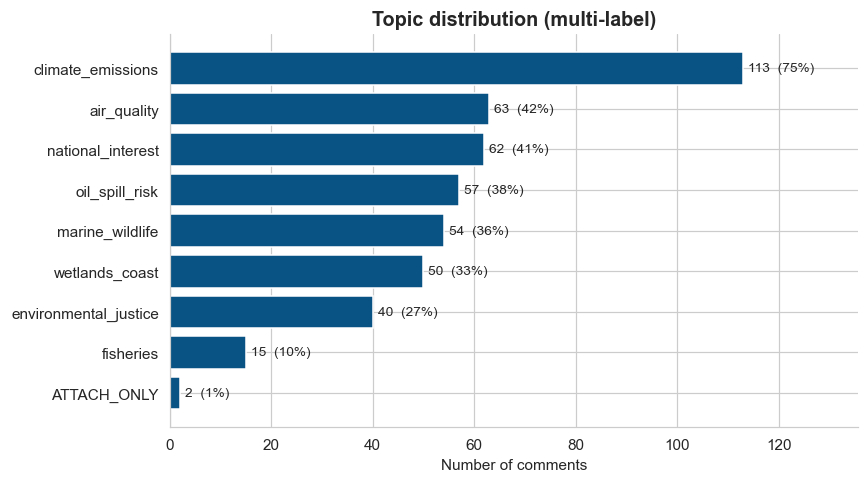

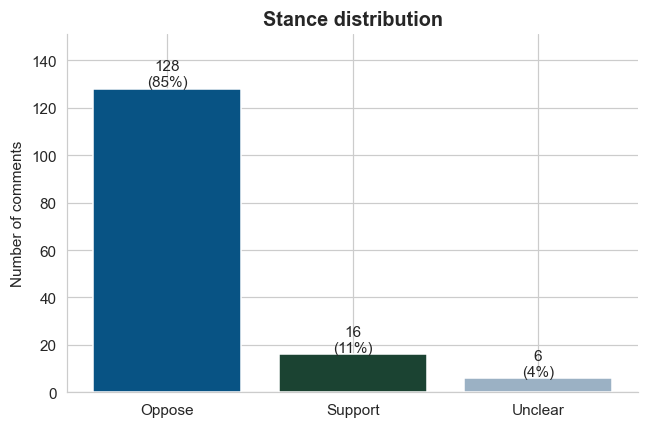

Sample: 150 comments
Opposed: 128 (85%)
Top topics: climate_emissions (113), air_quality (63), national_interest (62)


In [50]:

import pandas as pd, matplotlib.pyplot as plt
from collections import Counter

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Calibri', 'Arial', 'DejaVu Sans']   
NAVY, GREEN, GREY = '#085384', '#1B4332', '#9bb1c4'

df = pd.read_csv("label_done_150.csv")          
N = len(df)


c = Counter()
for s in df['gold_topics'].fillna('NONE'):
    for t in str(s).split('|'):
        if t and t != 'NONE':
            c[t] += 1
items  = sorted(c.items(), key=lambda x: x[1])
labels = [k for k, _ in items]
vals   = [v for _, v in items]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(labels, vals, color=NAVY)
for i, v in enumerate(vals):
    ax.text(v + 1, i, f'{v}  ({v/N*100:.0f}%)', va='center', fontsize=9)
ax.set_xlabel('Number of comments')
ax.set_title('Topic distribution (multi-label)', fontsize=13, weight='bold')
ax.set_xlim(0, max(vals) * 1.2)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.savefig('demo_topic_distribution.png', dpi=150, facecolor='white')
plt.show()

#  Stance 
order = ['oppose', 'support', 'unclear']
sc    = df['gold_stance'].fillna('unclear').value_counts()
svals = [int(sc.get(s, 0)) for s in order]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([s.capitalize() for s in order], svals, color=[NAVY, GREEN, GREY])
for i, v in enumerate(svals):
    ax.text(i, v + 1, f'{v}\n({v/N*100:.0f}%)', ha='center', fontsize=10)
ax.set_ylabel('Number of comments')
ax.set_title('Stance distribution', fontsize=13, weight='bold')
ax.set_ylim(0, max(svals) * 1.18)
for sp in ['top', 'right']:
    ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.savefig('demo_stance_distribution.png', dpi=150, facecolor='white')
plt.show()

print(f"Sample: {N} comments")
print(f"Opposed: {svals[0]} ({svals[0]/N*100:.0f}%)")
print(f"Top topics: " + ", ".join(f'{k} ({v})' for k, v in c.most_common(3)))

In [51]:

import pandas as pd, numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

TOPIC_CODES=['oil_spill_risk','climate_emissions','air_quality','environmental_justice',
             'marine_wildlife','fisheries','wetlands_coast','national_interest']

gold = pd.read_csv("label_done_150.csv")           
llm  = pd.read_csv("full_llm_UNIQUE.csv")          

m = gold.merge(llm[['Document ID','llm_topics','llm_stance','llm_failed']],
               on='Document ID', how='left')

m = m[m['llm_failed'] != True].copy()
print(f"access {len(m)} rows(exclude failed LLM )")

def parse(s): return [t for t in str(s).replace(' ','').split('|') if t in TOPIC_CODES]
mlb = MultiLabelBinarizer(classes=TOPIC_CODES)
Y = mlb.fit_transform(m['gold_topics'].apply(parse))     
P = mlb.transform(m['llm_topics'].apply(parse))          

print("TOPIC — LLM vs gold")
for avg in ['micro','macro']:
    p,r,f,_ = precision_recall_fscore_support(Y,P,average=avg,zero_division=0)
    print(f"  {avg}: Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}")

p,r,f,sup = precision_recall_fscore_support(Y,P,average=None,zero_division=0,labels=range(len(TOPIC_CODES)))
tbl = pd.DataFrame({'topic':TOPIC_CODES,'support':sup,'precision':p,'recall':r,'f1':f}).round(2)
print(tbl.to_string(index=False))

# LLM stance vs gold
gs = m['gold_stance'].str.lower()
ls = m['llm_stance'].str.lower()
print(f"\nSTANCE — LLM vs gold accuracy = {accuracy_score(gs,ls):.3f}")

access 138 rows(exclude failed LLM )
TOPIC — LLM vs gold
  micro: Precision=0.691  Recall=0.903  F1=0.783
  macro: Precision=0.671  Recall=0.894  F1=0.752
                topic  support  precision  recall   f1
       oil_spill_risk       53       0.77    0.89 0.82
    climate_emissions      105       0.91    1.00 0.95
          air_quality       60       0.70    0.92 0.79
environmental_justice       36       0.40    0.97 0.56
      marine_wildlife       51       0.81    0.94 0.87
            fisheries       13       0.46    0.92 0.62
       wetlands_coast       47       0.51    0.74 0.61
    national_interest       56       0.81    0.77 0.79

STANCE — LLM vs gold accuracy = 0.978


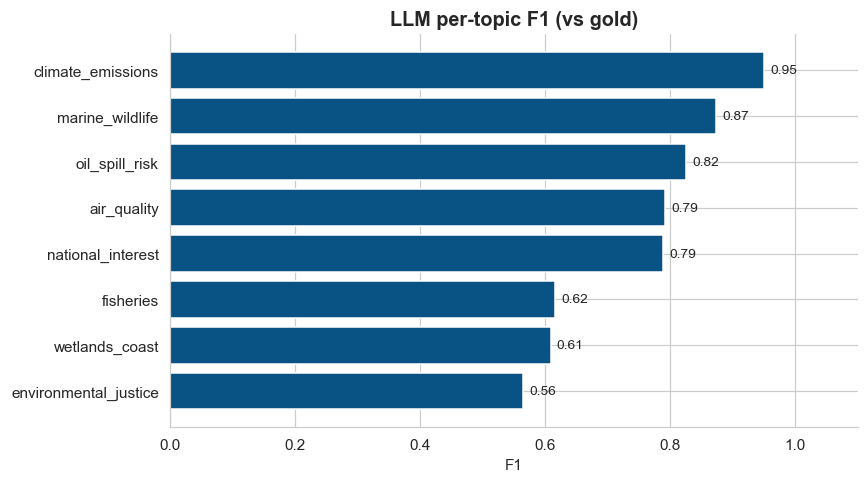

In [52]:
import matplotlib.pyplot as plt, numpy as np
plt.rcParams['font.family']='sans-serif'
NAVY='#085384'
order=np.argsort(f)
fig,ax=plt.subplots(figsize=(8,4.5))
ax.barh([TOPIC_CODES[i] for i in order],[f[i] for i in order],color=NAVY)
for y,i in enumerate(order): ax.text(f[i]+0.01,y,f"{f[i]:.2f}",va="center",fontsize=9)
ax.set_xlim(0,1.1); ax.set_xlabel('F1')
ax.set_title("LLM per-topic F1 (vs gold)",fontsize=13,weight="bold")
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.savefig("llm_per_topic_f1.png",dpi=150,facecolor="white"); plt.show()

In [53]:
full = pd.read_csv("cleaned_comments_ver2.csv")

uniq = full.drop_duplicates(subset=["comment_text"]).copy()
uniq = uniq[uniq["comment_text"].astype(str).str.strip().str.len()>0]
print(f"FULL {len(full)} -> unique {len(uniq)} comment need to run")

FULL 10195 -> unique 6574 comment need to run


In [54]:
import pandas as pd, os
from concurrent.futures import ThreadPoolExecutor, as_completed


done_ids=set()
if os.path.exists("full_llm_UNIQUE.csv"):
    prev=pd.read_csv("full_llm_UNIQUE.csv")
    done_ids=set(prev["Document ID"].astype(str))
    print("done", len(done_ids), "comment,skip")

todo = uniq[~uniq["Document ID"].astype(str).isin(done_ids)].to_dict("records")
print("Still need", len(todo), "comment")

def work(row):
    o=llm_label(row["comment_text"])
    return {"Document ID":row["Document ID"],
            "comment_text":row["comment_text"],
            "llm_topics":"|".join(o["topics"]) or "NONE",
            "llm_stance":o.get("stance","unclear"),
            "llm_conf":o.get("confidence",0.0),
            "llm_failed":o.get("FAILED",False)}

recs=[]
if done_ids: recs=prev.to_dict("records")  

done=0
with ThreadPoolExecutor(max_workers=8) as ex:      
    futs=[ex.submit(work,r) for r in todo]
    for f in as_completed(futs):
        recs.append(f.result()); done+=1
        if done%50==0:                             
            nfail=sum(r["llm_failed"] for r in recs)
            print(f"{done}/{len(todo)}  failed:{nfail}")
            pd.DataFrame(recs).to_csv("full_llm_UNIQUE.csv",index=False)

pd.DataFrame(recs).to_csv("full_llm_UNIQUE.csv",index=False)
print("FIN! SUM", len(recs), "comment")

done 6574 comment,skip
Still need 0 comment
FIN! SUM 6574 comment


In [55]:
uniq_lab = pd.read_csv("full_llm_UNIQUE.csv")[["comment_text","llm_topics","llm_stance","llm_conf"]]
full_lab = full.merge(uniq_lab, on="comment_text", how="left")
full_lab.to_csv("full_llm_ALL.csv",index=False)   
print("ALL DONE:", len(full_lab))

ALL DONE: 10195
